In [2]:
# Sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

# Load dataset
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum04/datasets/calonpembelimobil.csv', sep=',')

# Cetak header data
df.head()

Mounted at /content/gdrive


,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [3]:
# Import library dasar dan konfigurasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

# Matplotlib setting
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)

In [4]:
# Informasi kolom dan ringkasan statistik
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


,count,mean,std,min,25%,50%,75%,max
ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Usia,1000.0,43.532,12.672078,24.0,33.00,43.0,53.00,164.0
Status,1000.0,1.469,1.073402,0.0,1.00,1.0,2.00,3.0
Kelamin,1000.0,0.481,0.499889,0.0,0.00,0.0,1.00,1.0
Memiliki_Mobil,1000.0,0.952,0.801460,0.0,0.00,1.0,2.00,4.0
Penghasilan,1000.0,270.090,95.236810,95.0,187.00,258.5,352.25,490.0
Beli_Mobil,1000.0,0.633,0.482228,0.0,0.00,1.0,1.00,1.0


In [5]:
# Cek nilai unik untuk tiap kolom & missing values
for col in df.columns:
    print(f"{col:15} | unique: {df[col].nunique():3} | sample unique vals: {df[col].unique()[:10]}")
print("\nMissing values per column:\n", df.isna().sum())

ID              | unique: 1000 | sample unique vals: [ 1  2  3  4  5  6  7  8  9 10]
Usia            | unique:  44 | sample unique vals: [32 49 52 26 45 39 38 29 30 51]
Status          | unique:   4 | sample unique vals: [1 2 3 0]
Kelamin         | unique:   2 | sample unique vals: [0 1]
Memiliki_Mobil  | unique:   5 | sample unique vals: [0 1 2 4 3]
Penghasilan     | unique: 314 | sample unique vals: [240 100 250 130 237 280 150 143 200 174]
Beli_Mobil      | unique:   2 | sample unique vals: [1 0]

Missing values per column:
 ID                0
Usia              0
Status            0
Kelamin           0
Memiliki_Mobil    0
Penghasilan       0
Beli_Mobil        0
dtype: int64


In [6]:
# Pilih fitur dan target. Drop ID (identifier)
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Tentukan target dan fitur kandidat
target_col = 'Beli_Mobil'
candidate_features = ['Usia', 'Status', 'Kelamin', 'Memiliki_Mobil', 'Penghasilan']
features = [c for c in candidate_features if c in df.columns]

print("Features used:", features)
print("Target:", target_col)

Features used: ['Usia', 'Status', 'Kelamin', 'Memiliki_Mobil', 'Penghasilan']
Target: Beli_Mobil


In [7]:
# Periksa missing pada fitur yang dipilih dan tipe datanya
print(df[features + [target_col]].isna().sum())
print("\nDtypes:\n", df[features].dtypes)

Usia              0
Status            0
Kelamin           0
Memiliki_Mobil    0
Penghasilan       0
Beli_Mobil        0
dtype: int64

Dtypes:
 Usia              int64
Status            int64
Kelamin           int64
Memiliki_Mobil    int64
Penghasilan       int64
dtype: object


In [11]:
# Tentukan kolom numerik dan kategorikal untuk pra-pemrosesan
# Jika suatu kolom bertipe object maka dianggap kategorikal
# Bila semua numeric, maka categorical_cols akan kosong ([])

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Pisahkan kolom numerik dan kategorikal
categorical_cols = [c for c in features if df[c].dtype == 'object']
numeric_cols = [c for c in features if c not in categorical_cols]

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

# Preprocessor: scale numeric, one-hot encode categorical
# drop='first' untuk menghindari multikolinearitas
# sparse_output=False digunakan pada scikit-learn versi terbaru (≥1.2)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

Numeric cols: ['Usia', 'Status', 'Kelamin', 'Memiliki_Mobil', 'Penghasilan']
Categorical cols: []


In [12]:
# Pisahkan data menjadi train dan test set
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = df[features].copy()
y = df[target_col].copy()

# Gunakan stratify untuk menjaga proporsi kelas target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (800, 5)
Test size : (200, 5)


In [13]:
# Bangun pipeline (preprocessing + Logistic Regression) dan latih
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('pre', preprocessor),
    ('logreg', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42
    ))
])

# Latih model pada data training
clf.fit(X_train, y_train)
print("✅ Model berhasil dilatih.")

✅ Model berhasil dilatih.


In [14]:
# Prediksi dan evaluasi model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Prediksi label & probabilitas
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Hitung metrik evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9300
Precision: 0.9829
Recall   : 0.9055
F1-score : 0.9426
ROC-AUC  : 0.9768

Confusion Matrix:
[[ 71   2]
 [ 12 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        73
           1       0.98      0.91      0.94       127

    accuracy                           0.93       200
   macro avg       0.92      0.94      0.93       200
weighted avg       0.94      0.93      0.93       200



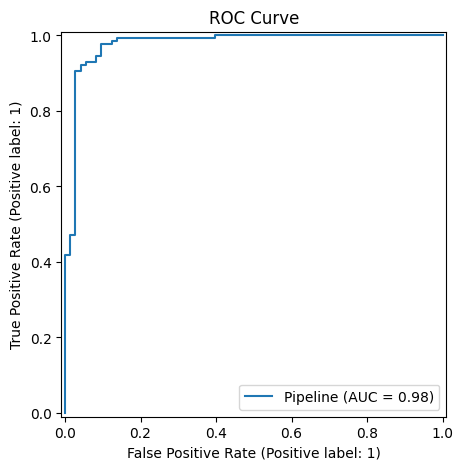

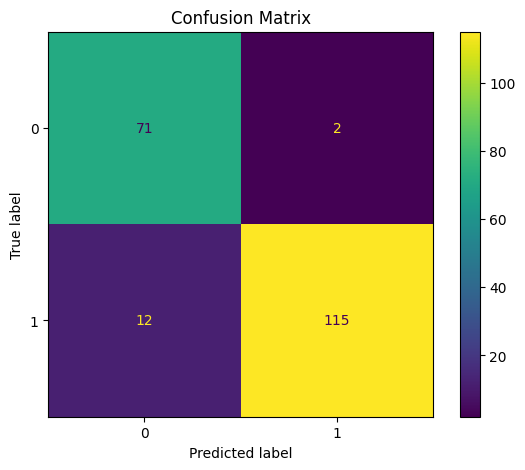

In [15]:
# Plot ROC Curve dan Confusion Matrix
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC Curve")
plt.show()

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [16]:
# Validasi silang 5-fold untuk estimasi performa
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy: {:.4f} ± {:.4f}".format(cv_scores.mean(), cv_scores.std()))

Cross-validation scores: [0.78  0.925 0.955 0.945 0.94 ]
Mean CV accuracy: 0.9090 ± 0.0652


In [17]:
# Melihat pengaruh fitur (koefisien Logistic Regression)

def get_feature_names(column_transformer):
    feature_names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            try:
                names = list(trans.get_feature_names_out(cols))
            except Exception:
                names = list(cols)
        else:
            names = list(cols)
        feature_names.extend(names)
    return feature_names

feat_names = get_feature_names(clf.named_steps['pre'])
coeffs = clf.named_steps['logreg'].coef_.flatten()

feat_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coeffs})
feat_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

,Feature,Coefficient
0,Penghasilan,4.568333
1,Memiliki_Mobil,0.078968
2,Usia,-0.045073
3,Status,-0.132093
4,Kelamin,-0.596863


In [18]:
# Dataset baru (contoh calon pembeli)
new_samples = pd.DataFrame([
    {'Usia': 25, 'Status': 1, 'Kelamin': 1, 'Memiliki_Mobil': 0, 'Penghasilan': 300},
    {'Usia': 40, 'Status': 2, 'Kelamin': 0, 'Memiliki_Mobil': 1, 'Penghasilan': 150},
    {'Usia': 30, 'Status': 1, 'Kelamin': 0, 'Memiliki_Mobil': 0, 'Penghasilan': 500},
    {'Usia': 22, 'Status': 0, 'Kelamin': 1, 'Memiliki_Mobil': 0, 'Penghasilan': 80},
    {'Usia': 50, 'Status': 3, 'Kelamin': 1, 'Memiliki_Mobil': 1, 'Penghasilan': 700},
])

# Urutkan kolom sesuai fitur
new_samples = new_samples[features]

# Prediksi
new_pred = clf.predict(new_samples)
new_proba = clf.predict_proba(new_samples)[:, 1]

# Gabungkan hasil
result_df = new_samples.copy()
result_df['Predicted_Beli_Mobil'] = new_pred
result_df['Prob_Beli_Mobil'] = new_proba.round(4)

result_df

,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Predicted_Beli_Mobil,Prob_Beli_Mobil
0,25,1,1,0,300,1,0.9390
1,40,2,0,1,150,0,0.0327
2,30,1,0,0,500,1,1.0000
3,22,0,1,0,80,0,0.0004
4,50,3,1,1,700,1,1.0000


In [24]:
# Simpan model Logistic Regression ke file .joblib
import joblib

joblib.dump(clf, 'logreg_calonpembeli_model.joblib')
joblib.dump(clf, '/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum04/models/model_final.pkl')
print("✅ Model disimpan sebagai 'logreg_calonpembeli_model.joblib' dan file mode_final.pkl")


✅ Model disimpan sebagai 'logreg_calonpembeli_model.joblib' dan file mode_final.pkl
